<a href="https://colab.research.google.com/github/m1deey/Loan_pediction/blob/main/01_Vasules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import pandas as pd
df=pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [111]:
df.columns=df.columns.str.strip()

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   loan_id           4269 non-null   int64 
 1   no_of_dependents  4269 non-null   int64 
 2   education         4269 non-null   object
 3   self_employed     4269 non-null   object
 4   income_annum      4269 non-null   int64 
 5   loan_amount       4269 non-null   int64 
 6   loan_term         4269 non-null   int64 
 7   cibil_score       4269 non-null   int64 
 8   loan_status       4269 non-null   object
 9   total_assets      4269 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 333.6+ KB


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,total_assets
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,3.254877e+07
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,1.950656e+07
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,4.000000e+05
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,1.630000e+07
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,3.150000e+07
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,4.720000e+07
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,9.070000e+07


In [ ]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#Vasuels

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

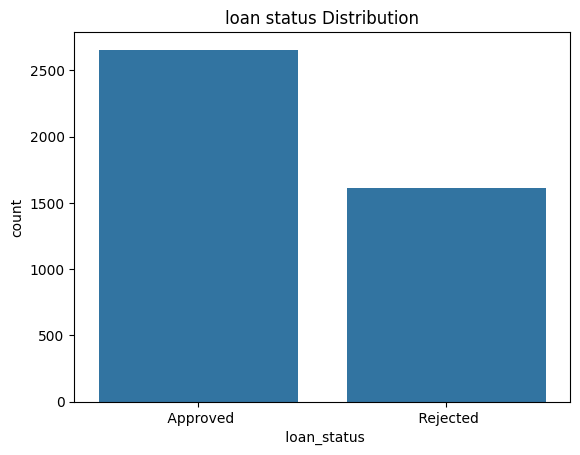

In [ ]:
sns.countplot(x=" loan_status",data=df)
plt.title("loan status Distribution")
plt.show()

The dataset contains more approved loans than rejected loans, indicating that the classes are moderately imbalanced.

I am going to sum the assets and put them in one column to save time

In [112]:

df['total_assets'] = (df['residential_assets_value'] +
                       df['commercial_assets_value'] +
                       df['luxury_assets_value'] +
                       df['bank_asset_value'])

df = df.drop(['residential_assets_value', 'commercial_assets_value',
              'luxury_assets_value', 'bank_asset_value'], axis=1)
df=df.drop("loan_id",axis=1)
print(df.columns)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'loan_status',
       'total_assets'],
      dtype='object')


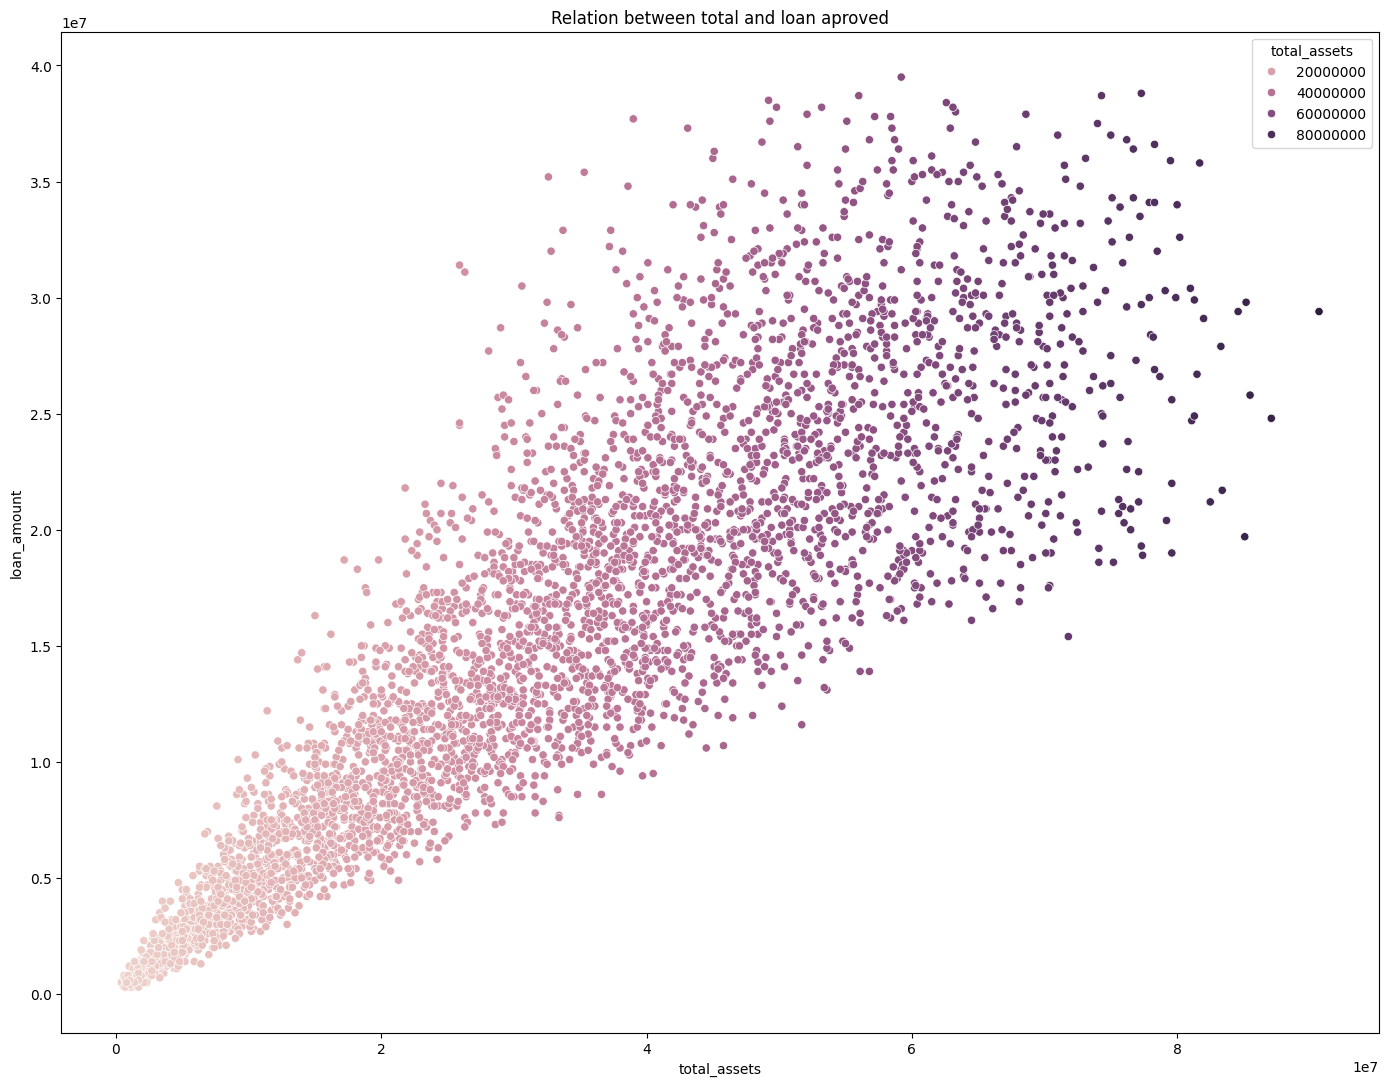

In [ ]:
plt.figure(figsize=(17,13))
sns.scatterplot(data=df,x="total_assets",y="loan_amount",hue="total_assets")
plt.title("Relation between total and loan aproved")
plt.show()

Applicants with higher total assets generally receive larger loan amounts, suggesting a positive relationship between total assets and loan amount.

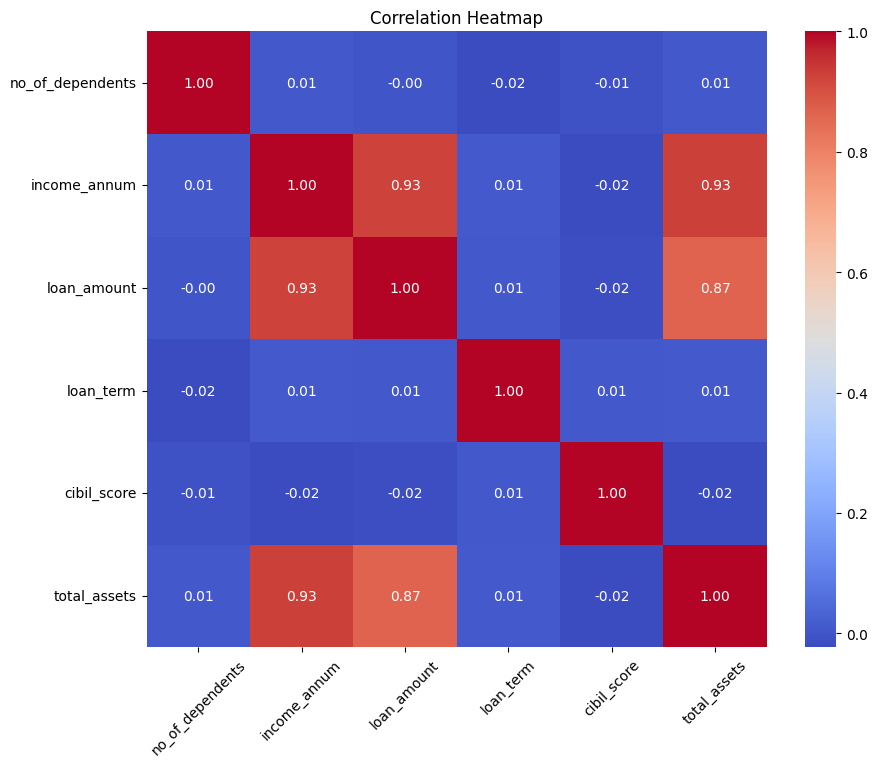

In [114]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.xticks(rotation=45)
plt.show()

income_annum, loan_amount, and total_assets show a strong positive correlation. Additionally, applicants with higher CIBIL scores are more likely to have their loans approved.

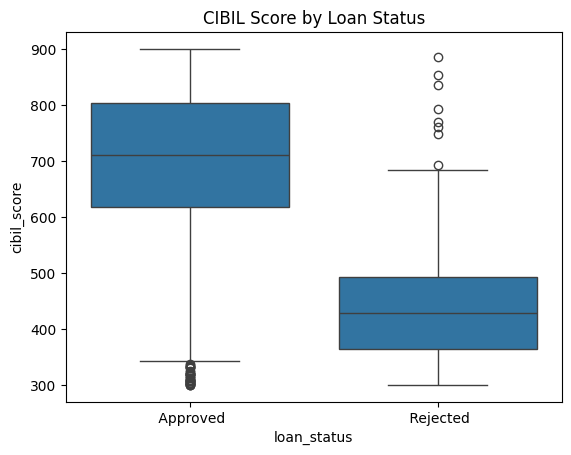

In [115]:
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title('CIBIL Score by Loan Status')
plt.show()

The ones who have more cbil score have a higher chance to be aproved

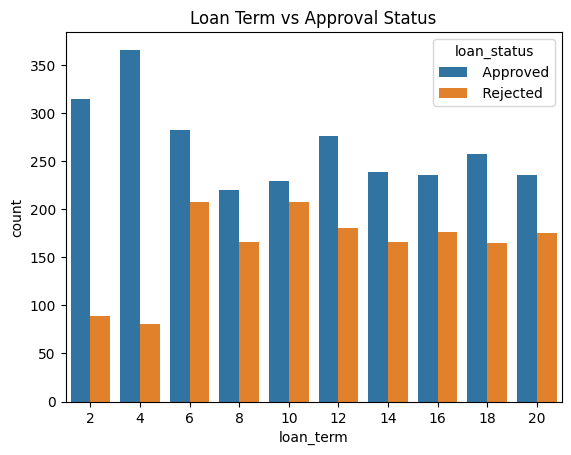

In [116]:
sns.countplot(x='loan_term', hue='loan_status', data=df)
plt.title('Loan Term vs Approval Status')
plt.show()

Shorter loan terms are associated with a lower rejection rate, while longer loan terms appear to have a higher proportion of rejected applications.

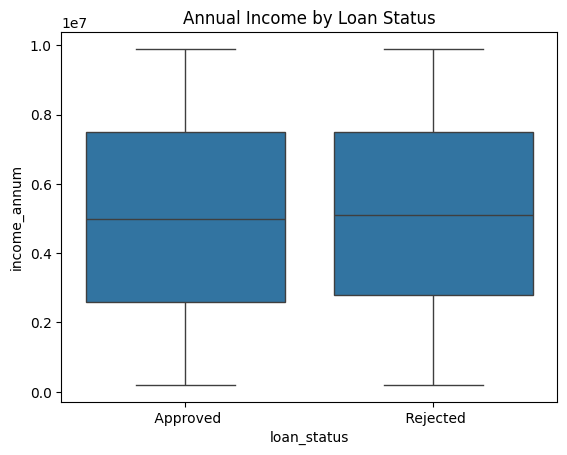

In [117]:
sns.boxplot(x='loan_status', y='income_annum', data=df)
plt.title('Annual Income by Loan Status')
plt.show()

In [132]:
df["asset_group"] = pd.cut(
    df["total_assets"],
    bins=5
)
ss=df["

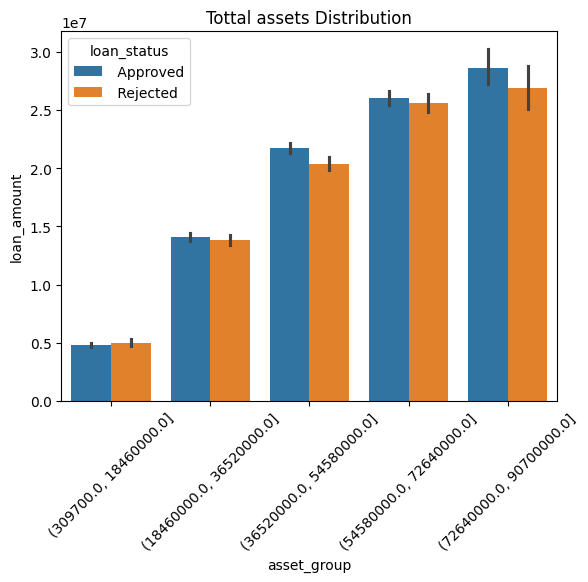

In [140]:
sns.barplot(data=df,x="asset_group",y="loan_amount",hue="loan_status")
plt.title("Tottal assets Distribution")
plt.xticks(rotation=45)
plt.show()

total assets increase, the loan amount also tends to increase, indicating that applicants with greater assets are eligible for larger loans.

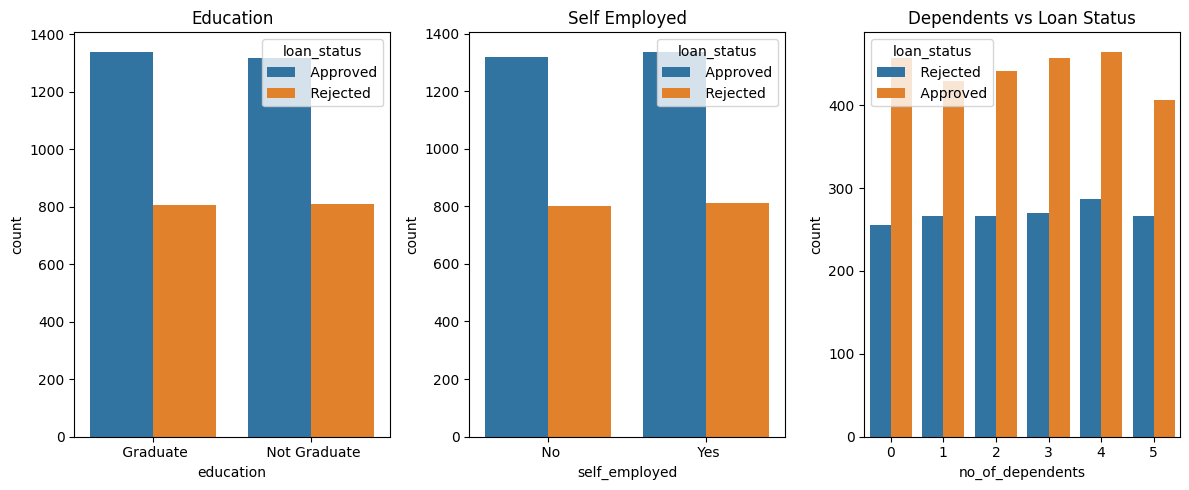

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.countplot(data=df, x="education", hue="loan_status", ax=axes[0])
axes[0].set_title("Education")

sns.countplot(data=df, x="self_employed", hue="loan_status", ax=axes[1])
axes[1].set_title("Self Employed")

sns.countplot(x='no_of_dependents', hue='loan_status' ,data=df,ax=axes[2])
axes[2].set_title('Dependents vs Loan Status')

plt.tight_layout()
plt.show()

Education level, self-employment status, and number of dependents do not show a noticeable relationship with loan approval. The distribution of approved and rejected loans is similar across these categories.

#Final Conclusions
The dataset contains more approved loans than rejected loans.
Applicants with higher CIBIL scores have a significantly higher chance of loan approval.

Income, loan amount, and total assets are strongly positively correlated.

Applicants with higher total assets generally qualify for larger loan amounts.

Shorter loan terms appear to have a lower rejection rate than longer loan terms.

Education level, self-employment status, and number of dependents show little to no clear relationship with loan approval.